In [36]:
import numpy as np
from pathlib import Path
import sys
import os
import scipy
from scipy.stats import norm
import matplotlib.pyplot as plt

In [58]:
# load data
# sim_id = 92
sim_id = 0

save_path = Path('../data') / 'results'
discrims = np.load(Path(save_path) / f'sim_{sim_id:04d}_1k_trials_discrim.npy')
# curvatures = np.load(Path(save_path) / f'sim_{sim_id:04d}_curvs_v4.npy')

mat2 = scipy.io.loadmat(Path('../data') / 'bin_sizes_all.mat')
bin_sizes_all = mat2['bin_sizes_all'][0][12:-2]

# load corresponding sample neural responses
data_path = Path('../data')
f_name = f'sim_{sim_id:04d}.mat' # slow sensory-driven time scale
S = scipy.io.loadmat(Path(data_path) / f_name)['S']
S_list = [S[0, i] for i in range(S.shape[1])]  # convert to list of structs

In [59]:
# convert bin size to number of bins
dt = S_list[0]['dt'][0, 0]
T = S_list[0]['T'][0, 0]
n_timepoints = T / dt
n_bins = np.zeros(len(bin_sizes_all))

for j, bin_size in enumerate(bin_sizes_all):
    bin_length = int((bin_size / dt.item()))
    n_bins[j] = int((n_timepoints // bin_length))
    # bin_length = int((bin_size / dt))
    # n_bins[j] = int((n_timepoints // bin_length))

print(bin_sizes_all)
print(n_bins)

[0.05  0.055 0.088 0.1   0.11  0.2   0.22  0.275 0.44  0.55 ]
[44. 40. 25. 22. 20. 11. 10.  8.  5.  4.]


In [60]:
# get population sizes
# n_neurons = np.zeros(len(S_list))
# for ipop in range(len(S_list)):
#     n_neurons[ipop] = S_list[ipop]['n_neuron'][0,0]
n_neurons = [2, 4, 8, 10, 20, 40, 50, 100]
# chance = 1 / n_bins

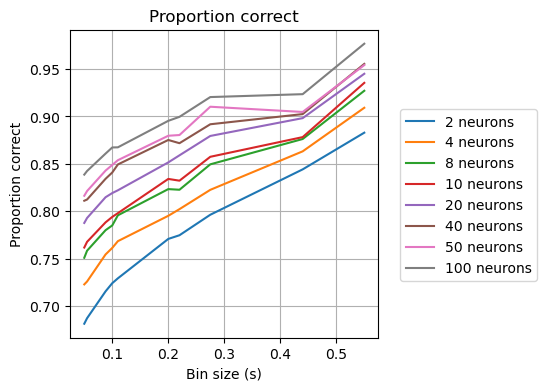

In [62]:
# plot data in proportion correct
fig, axs = plt.subplots(figsize=(6.5, 4))
# axs.plot(bin_sizes_all, chance, 'k--', label='Chance level')

for i in range(len(n_neurons)):
    axs.plot(bin_sizes_all, discrims[i], label=f'{int(n_neurons[i])} neurons')
    axs.set_title('Proportion correct')
    axs.set_xlabel('Bin size (s)')
    axs.set_ylabel('Proportion correct')
    axs.set_box_aspect(1)
    axs.grid(True)
fig.legend(loc='outside right')

plt.show()

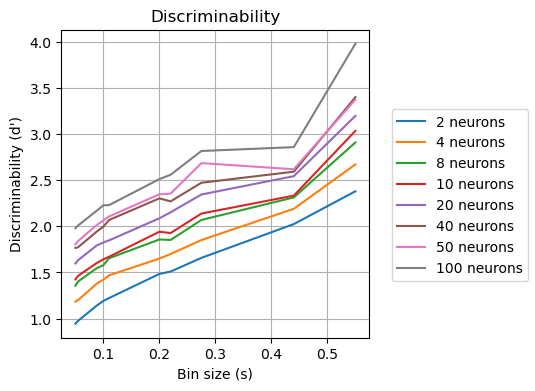

In [63]:
# plot data in d'
X = norm(0, 1)
fig, axs = plt.subplots(figsize=(6.5, 4))
# axs.plot(bin_sizes_all, 2 * X.ppf(chance), 'k--', label='Chance level')

for i in range(len(n_neurons)):
    axs.plot(bin_sizes_all, 2 * X.ppf(discrims[i]), label=f'{int(n_neurons[i])} neurons')
    axs.set_title('Discriminability')
    axs.set_xlabel('Bin size (s)')
    axs.set_ylabel("Discriminability (d')")
    axs.set_box_aspect(1)
    axs.grid(True)
fig.legend(loc='outside right')
plt.show()

In [ ]:
# # plot data in d'
# X = norm(0, 1)
# fig, axs = plt.subplots(1, 2, figsize=(10, 4))
# axs[0].plot(bin_sizes_all, 2 * X.ppf(chance), 'k--', label='Chance level')

# for i in range(len(n_neurons)):
#     axs[0].plot(bin_sizes_all, 2 * X.ppf(discrims[i]), label=f'{int(n_neurons[i])} neurons')
#     axs[0].set_title('Discriminability')
#     axs[0].set_xlabel('Bin size (s)')
#     axs[0].set_ylabel("Discriminability (d')")
#     axs[0].set_box_aspect(1)
#     axs[0].grid(True)
#     axs[0].legend()


#     axs[1].plot(bin_sizes_all, curvatures[i], label=f'{int(n_neurons[i])} neurons')
#     axs[1].set_title('Curvatures')
#     axs[1].set_xlabel('Bin size (s)')
#     axs[1].set_ylabel('Curvature (deg)')
#     axs[1].set_box_aspect(1)